# Bayesian Hierarchical Analysis of CMS Hospital Ratings

**Angela Holm**  
Healthcare Analytics | Python | Bayesian Modeling

---

## Project Overview

This project examines patterns in Medicare hospital quality ratings using publicly available hospital data from the Centers for Medicare & Medicaid Services (CMS). The analysis focuses on whether selected hospital characteristics and quality measures are associated with differences in overall hospital ratings.

Python was used to prepare and analyze the data, while PyMC was used to develop a Bayesian hierarchical model. The model examines hospital overall ratings in relation to emergency service availability, mortality performance, and readmission performance while also accounting for differences among state or territory groups.

The project demonstrates an end-to-end healthcare analytics workflow that includes data preparation, feature engineering, statistical modeling, Bayesian inference, model diagnostics, visualization, and interpretation of hospital performance measures.

### Tools and Methods

- **Python:** Primary programming language for the analysis
- **Pandas and NumPy:** Data preparation, transformation, and numerical operations
- **PyMC:** Bayesian hierarchical modeling and MCMC sampling
- **ArviZ:** Posterior analysis, convergence diagnostics, and visualization
- **Matplotlib:** Visualization and presentation of model results
- **Analytical Methods:** Data cleaning, categorical encoding, standardization, hierarchical modeling, posterior estimation, model diagnostics, and interpretation

### Analysis Dataset

- **Original dataset:** 5,432 hospitals and 38 variables
- **Final modeling dataset:** 3,179 hospitals
- **Geographic groups:** 54 state/territory groups
- **Outcome:** Hospital Overall Rating
- **Hospital-level predictors:** Emergency Services, Mortality Performance, and Readmission Performance

## 1. Python Libraries and Environment

The analysis begins by importing the Python libraries needed for data preparation, Bayesian modeling, statistical analysis, and visualization. pandas and NumPy are used to work with the hospital data, while PyMC provides the Bayesian modeling framework. ArviZ is used to summarize posterior distributions and evaluate model diagnostics, and Matplotlib is available for visualization.

The installed PyMC and ArviZ versions are also displayed to document the analytical environment used for the project.

In [39]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

print("PyMC version:", pm.__version__)
print("ArviZ version:", az.__version__)

PyMC version: 5.28.5
ArviZ version: 0.23.4


## 2. Data Loading and Initial Review

The CMS Hospital General Information dataset is loaded into a pandas DataFrame. The dimensions of the dataset are checked to confirm the number of observations and variables, and the first several records are displayed to review the structure of the data.

The original dataset contains 5,432 hospital records and 38 variables describing hospital characteristics and quality measures.

In [40]:
hospital_data = pd.read_csv("Hospital_General_Information.csv")

print("Dataset successfully loaded.")
print("Dataset dimensions:", hospital_data.shape)

hospital_data.head()

Dataset successfully loaded.
Dataset dimensions: (5432, 38)


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,1,9,1,NaN,15,15,NaN,10,10,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,1,8,0,NaN,15,15,NaN,10,10,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,1,8,0,NaN,15,15,NaN,10,9,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,0,3,2,NaN,15,5,NaN,10,7,NaN
4,010011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,(205) 838-3122,Acute Care Hospitals,Voluntary non-profit - Private,...,1,5,2,29.0,15,10,29.0,10,7,29.0


## 3. Data Cleaning and Preparation

### Removing Unavailable Hospital Ratings

Hospital overall rating is the outcome used in this analysis. Hospitals without an available overall rating are removed because they cannot contribute to the statistical model.

After filtering these records, the distribution of the remaining ratings is reviewed. CMS hospital ratings range from 1 to 5, allowing the number of hospitals within each rating category to be examined before modeling.

In [41]:
hospital_data = hospital_data[
    hospital_data["Hospital overall rating"] != "Not Available"
].copy()

print(
    "Hospitals remaining after removing unavailable ratings:",
    len(hospital_data)
)

hospital_data[
    "Hospital overall rating"
].value_counts().sort_index()

Hospitals remaining after removing unavailable ratings: 3182


Hospital overall rating
1    199
2    662
3    987
4    950
5    384
Name: count, dtype: int64

### Converting Quality Measures to Numeric Values

The hospital rating, mortality performance, and readmission performance variables are converted to numeric data types so they can be used in the statistical analysis.

Values that cannot be converted are treated as missing. Missing-value counts are then reviewed to identify whether additional records need to be removed before constructing the model.

In [43]:
numeric_columns = [
    "Hospital overall rating",
    "Count of MORT Measures Better",
    "Count of READM Measures Better"
]

for column in numeric_columns:
    hospital_data[column] = pd.to_numeric(
        hospital_data[column],
        errors="coerce"
    )

print(hospital_data[numeric_columns].dtypes)

hospital_data[numeric_columns].isnull().sum()

Hospital overall rating             int64
Count of MORT Measures Better     float64
Count of READM Measures Better    float64
dtype: object


Hospital overall rating           0
Count of MORT Measures Better     3
Count of READM Measures Better    1
dtype: int64

### Creating the Modeling Dataset

A focused modeling dataset is created using the variables needed for the analysis: state, hospital overall rating, emergency service availability, mortality performance, and readmission performance.

Records containing missing values in these variables are removed to ensure that each hospital included in the Bayesian model has complete information. The resulting dataset contains 3,179 hospitals.

In [44]:
model_data = hospital_data[
    [
        "State",
        "Hospital overall rating",
        "Emergency Services",
        "Count of MORT Measures Better",
        "Count of READM Measures Better"
    ]
].copy()

model_data = model_data.dropna()

print("Final model dataset dimensions:", model_data.shape)

model_data.head()

Final model dataset dimensions: (3179, 5)


,State,Hospital overall rating,Emergency Services,Count of MORT Measures Better,Count of READM Measures Better
0,AL,4,Yes,0.0,1.0
1,AL,3,Yes,0.0,1.0
2,AL,2,Yes,0.0,1.0
3,AL,1,Yes,0.0,0.0
4,AL,3,Yes,0.0,1.0


## 4. Feature Engineering

### Encoding Emergency Service Availability

Emergency service availability is recorded as a categorical Yes/No variable in the original dataset. To use this information in the statistical model, the categories are converted to numeric values, with **1 representing hospitals that provide emergency services** and **0 representing hospitals that do not**.

After encoding, the distribution is reviewed to confirm the conversion. Of the 3,179 hospitals included in the analysis, 3,033 provide emergency services and 146 do not.

In [45]:
model_data["Emergency Services"] = (
    model_data["Emergency Services"]
    .map({"Yes": 1, "No": 0})
)

print(
    model_data["Emergency Services"]
    .value_counts(dropna=False)
    .sort_index()
)

model_data.head()

Emergency Services
0     146
1    3033
Name: count, dtype: int64


,State,Hospital overall rating,Emergency Services,Count of MORT Measures Better,Count of READM Measures Better
0,AL,4,1,0.0,1.0
1,AL,3,1,0.0,1.0
2,AL,2,1,0.0,1.0
3,AL,1,1,0.0,0.0
4,AL,3,1,0.0,1.0


### Creating State-Level Group Identifiers

Because hospitals are grouped geographically, the state variable is converted from state abbreviations into numeric category codes. These codes allow each hospital to remain associated with its state while providing the numeric indexing needed for the hierarchical Bayesian model.

The resulting state identifier is used to estimate state-level effects rather than treating every hospital as completely independent of its geographic group.

In [46]:
model_data["State_Code"] = (
    model_data["State"]
    .astype("category")
    .cat.codes
)

state_names = (
    model_data["State"]
    .astype("category")
    .cat.categories
)

print("Number of state groups:", len(state_names))
print("\nFirst 10 state groups:")
print(state_names[:10])

Number of state groups: 54

First 10 state groups:
Index(['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL'], dtype='str')


### Standardizing Hospital Performance Measures

The mortality and readmission performance variables are standardized before modeling. Standardization centers each variable around its mean and scales it by its standard deviation.

This places the two measures on a comparable scale and makes their model coefficients easier to interpret. The standardized variables, `MORT_std` and `READM_std`, represent how far each hospital's performance is above or below the average for the hospitals included in the analysis.

In [47]:
model_data["MORT_std"] = (
    model_data["Count of MORT Measures Better"]
    - model_data["Count of MORT Measures Better"].mean()
) / model_data["Count of MORT Measures Better"].std()

model_data["READM_std"] = (
    model_data["Count of READM Measures Better"]
    - model_data["Count of READM Measures Better"].mean()
) / model_data["Count of READM Measures Better"].std()

model_data[
    ["MORT_std", "READM_std"]
].agg(["mean", "std"]).round(3)

,MORT_std,READM_std
mean,-0.0,0.0
std,1.0,1.0


## 5. Preparing the Model Inputs

The cleaned data are separated into the components required by the Bayesian model.

The predictor matrix includes three hospital-level characteristics:

- Emergency service availability
- Standardized mortality performance
- Standardized readmission performance

Hospital overall rating serves as the outcome variable. A separate state index identifies the geographic group associated with each hospital and allows state-level variation to be incorporated into the hierarchical model.

The final model contains **3,179 hospital observations and three hospital-level predictors**.

In [48]:
predictors = [
    "Emergency Services",
    "MORT_std",
    "READM_std"
]

X = model_data[predictors].to_numpy(dtype=float)

y = model_data[
    "Hospital overall rating"
].to_numpy(dtype=float)

state_index = model_data[
    "State_Code"
].to_numpy(dtype=int)

print("Number of observations:", len(y))
print("Number of predictors:", len(predictors))
print("Predictor matrix shape:", X.shape)

Number of observations: 3179
Number of predictors: 3
Predictor matrix shape: (3179, 3)


## 6. Bayesian Hierarchical Model

A Bayesian hierarchical model is developed in PyMC to examine the relationship between hospital characteristics and Medicare overall hospital ratings.

The model estimates an overall intercept along with coefficients for emergency service availability, mortality performance, and readmission performance. A state-level random effect is also included to account for geographic differences among hospitals located within the same state or territory.

This structure allows the analysis to estimate overall relationships across hospitals while recognizing that hospital ratings may also vary by geographic group.

### Model Components

- **Outcome:** Hospital Overall Rating
- **Hospital-level predictors:** Emergency Services, Mortality Performance, and Readmission Performance
- **Group-level variable:** State
- **State-level variation:** Estimated through a hierarchical random effect
- **Residual variation:** Represents differences in hospital ratings not explained by the included predictors or state-level effects

In [49]:
coords = {
    "state": state_names.tolist(),
    "predictor": predictors
}

with pm.Model(coords=coords) as hierarchical_model:

    alpha = pm.Normal(
        "alpha",
        mu=0,
        sigma=10
    )

    beta = pm.Normal(
        "beta",
        mu=0,
        sigma=5,
        dims="predictor"
    )

    sigma_state = pm.HalfNormal(
        "sigma_state",
        sigma=5
    )

    state_effect = pm.Normal(
        "state_effect",
        mu=0,
        sigma=sigma_state,
        dims="state"
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=5
    )

    mu = (
        alpha
        + state_effect[state_index]
        + pm.math.dot(X, beta)
    )

    rating = pm.Normal(
        "rating",
        mu=mu,
        sigma=sigma,
        observed=y
    )

## 7. Posterior Sampling

Markov Chain Monte Carlo (MCMC) sampling is used to estimate the posterior distributions of the model parameters. Multiple independent chains are run so that convergence and sampling stability can be evaluated.

The sampling process produces posterior estimates for the hospital-level predictors, state-level variation, and remaining unexplained variation in hospital ratings. These posterior distributions provide both an estimated effect and a range of credible values for each model parameter.

In [50]:
with hierarchical_model:
    trace = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=2,
        target_accept=0.95,
        random_seed=42,
        return_inferencedata=True
    )

C:\Users\angel\anaconda3\envs\bayesian\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [alpha, beta, sigma_state, state_effect, sigma]


C:\Users\angel\anaconda3\envs\bayesian\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 50 seconds.


## 8. Posterior Results

The posterior distributions are summarized using ArviZ. For each model parameter, the output reports the posterior mean, standard deviation, 95% highest density interval (HDI), effective sample size, and R-hat convergence statistic.

The posterior estimates show the direction and magnitude of the relationships between the selected hospital characteristics and overall hospital ratings while also showing the uncertainty surrounding each estimate.

In [51]:
posterior_summary = az.summary(
    trace,
    var_names=[
        "alpha",
        "beta",
        "sigma_state",
        "sigma"
    ],
    hdi_prob=0.95,
    round_to=3
)

posterior_summary

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,3.522,0.095,3.335,3.702,0.002,0.001,3416.907,4741.837,1.000
beta[Emergency Services],-0.333,0.085,-0.504,-0.171,0.001,0.001,7045.341,5671.723,1.000
beta[MORT_std],0.291,0.018,0.255,0.324,0.000,0.000,13288.022,5440.553,1.000
beta[READM_std],0.320,0.017,0.286,0.354,0.000,0.000,13957.677,6293.182,1.000
sigma_state,0.293,0.040,0.219,0.375,0.001,0.000,5480.181,5919.003,1.001
sigma,0.946,0.012,0.921,0.969,0.000,0.000,15820.228,5525.115,1.000


### Interpretation of Posterior Estimates

The posterior results show clear relationships between the selected hospital characteristics and overall hospital ratings within this model.

The standardized mortality performance coefficient is approximately **0.291**, while the standardized readmission performance coefficient is approximately **0.320**. Both estimates are positive, indicating that hospitals performing better on these measures tend to have higher overall ratings when the other model components are held constant.

Emergency service availability has an estimated coefficient of approximately **−0.333**. Within this dataset and model, hospitals providing emergency services tend to have somewhat lower overall ratings after accounting for mortality performance, readmission performance, and state-level differences. This relationship should be interpreted as an association rather than evidence that providing emergency services causes lower ratings.

The estimated state-level standard deviation of approximately **0.293** also suggests that some variation in hospital ratings remains associated with geographic grouping after accounting for the hospital-level predictors.

## Visualization of Posterior Estimates

The posterior estimates for the three hospital-level predictors are visualized with their 95% highest density intervals (HDIs). This provides a clear comparison of the estimated direction, magnitude, and uncertainty of each relationship with hospital overall rating.

Values to the right of zero represent positive associations with hospital ratings, while values to the left represent negative associations. The 95% HDI shows the range containing 95% of the posterior probability for each estimated effect.

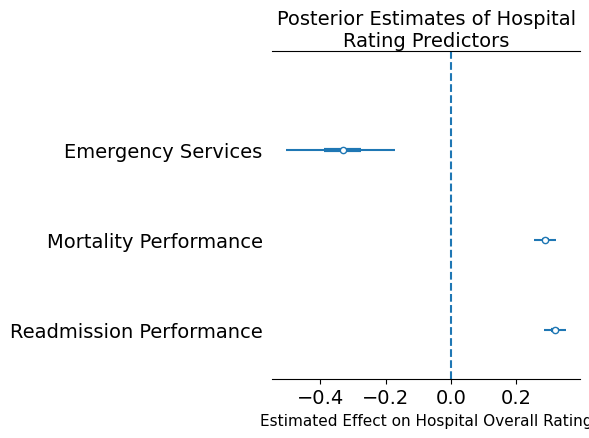

In [52]:
# Create a portfolio-ready posterior coefficient plot

ax = az.plot_forest(
    trace,
    var_names=["beta"],
    combined=True,
    hdi_prob=0.95
)

# Replace technical labels with reader-friendly labels
# Labels follow ArviZ's displayed bottom-to-top coefficient order
ax[0].set_yticklabels([
    "Readmission Performance",
    "Mortality Performance",
    "Emergency Services"
])

# Add reference line at zero
ax[0].axvline(0, linestyle="--")

# Add descriptive title and axis label
ax[0].set_title(
    "Posterior Estimates of Hospital Rating Predictors",
    fontsize=14
)

ax[0].set_xlabel(
    "Estimated Effect on Hospital Overall Rating",
    fontsize=11
)

# Adjust spacing
plt.tight_layout()

# Save a high-resolution copy for the GitHub README
plt.savefig(
    "posterior_plot.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the plot in the notebook
plt.show()

### Interpretation of the Posterior Estimates

The visualization shows a clear difference in the direction of the estimated relationships between the three hospital-level predictors and overall hospital ratings. Mortality and readmission performance are both positively associated with hospital overall ratings. The estimated effect for mortality performance is approximately 0.291, while the estimated effect for readmission performance is approximately 0.320.

Emergency service availability shows a negative association with hospital overall rating, with an estimated effect of approximately -0.333. This finding should not be interpreted to mean that providing emergency services causes lower hospital ratings. Hospitals with emergency services may differ in patient populations, case complexity, hospital characteristics, and other factors that are not included in this model.

The 95% HDIs for all three predictors remain on one side of zero, showing that the posterior distributions consistently support the direction of these relationships within the model.

## 9. Model Diagnostics

Model diagnostics are evaluated to determine whether the MCMC sampling process produced stable and reliable posterior estimates.

Three primary diagnostics are reviewed:

- **R-hat** evaluates whether the independent sampling chains converged toward the same posterior distribution.
- **Effective Sample Size (ESS)** estimates the amount of useful information contained in the correlated MCMC samples.
- **Divergent transitions** identify sampling problems that can indicate difficulty exploring the posterior distribution.

Together, these measures help determine whether the posterior estimates can be interpreted with confidence.

In [53]:
maximum_rhat = posterior_summary["r_hat"].max()

minimum_bulk_ess = posterior_summary["ess_bulk"].min()

minimum_tail_ess = posterior_summary["ess_tail"].min()

divergences = int(
    trace.sample_stats["diverging"].sum().values
)

print("Maximum R-hat:", maximum_rhat)
print("Minimum Bulk ESS:", minimum_bulk_ess)
print("Minimum Tail ESS:", minimum_tail_ess)
print("Number of Divergent Transitions:", divergences)

Maximum R-hat: 1.001
Minimum Bulk ESS: 3416.907
Minimum Tail ESS: 4741.837
Number of Divergent Transitions: 0


### Diagnostic Results

The model produced strong sampling diagnostics. The maximum R-hat value was **1.001**, indicating excellent agreement among the sampling chains. The minimum bulk effective sample size was approximately **3,417**, and the minimum tail effective sample size was approximately **4,742**, providing substantial effective posterior samples for inference.

The sampler also reported **zero divergent transitions**. Taken together, these results indicate that the MCMC chains converged successfully and that no major sampling problems were identified.

## 10. Descriptive Statistics

Descriptive statistics are calculated for the continuous variables used in the analysis to provide additional context for the modeled hospital population.

The summary includes the hospital overall rating and the original mortality and readmission performance measures before standardization. Measures such as the mean, standard deviation, minimum, quartiles, and maximum provide a general view of how these characteristics are distributed across the 3,179 hospitals included in the final dataset.

In [54]:
# Descriptive statistics for the continuous variables

model_data[
    [
        "Hospital overall rating",
        "Count of MORT Measures Better",
        "Count of READM Measures Better"
    ]
].describe().round(2)

,Hospital overall rating,Count of MORT Measures Better,Count of READM Measures Better
count,3179.00,3179.00,3179.00
mean,3.21,0.36,0.68
std,1.09,0.91,0.89
min,1.00,0.00,0.00
25%,2.00,0.00,0.00
50%,3.00,0.00,0.00
75%,4.00,0.00,1.00
max,5.00,8.00,8.00


In [34]:
# Frequency of hospitals with and without emergency services

model_data["Emergency Services"].value_counts()

Emergency Services
1    3033
0     146
Name: count, dtype: int64

## Limitations

Several limitations should be considered when interpreting the results of this analysis. The model examines associations among selected hospital characteristics and overall hospital ratings, so the results should not be interpreted as causal relationships. Hospital performance can be influenced by many factors that are not included in the model, including patient populations, case complexity, hospital size, available services, and other organizational or regional characteristics.

The hospital overall rating is also an ordered rating from 1 to 5. For this analysis, it is modeled as a numeric outcome using a normal likelihood. A future analysis could explore an ordinal modeling approach that more directly reflects the ordered structure of the rating scale.

Finally, the analysis represents the hospitals and measures available in the dataset used for this project. Results may change as hospital performance data and rating methodologies are updated.

## 11. Key Findings and Conclusion

This analysis used Medicare hospital data to examine how selected quality and operational characteristics relate to overall hospital ratings while accounting for geographic differences among hospitals.

The Bayesian hierarchical model identified positive relationships between better mortality and readmission performance and higher hospital ratings. Readmission performance showed a slightly larger estimated relationship with hospital ratings than mortality performance within the model. Emergency service availability was associated with lower ratings after accounting for the other predictors and state-level effects; however, this finding should not be interpreted as a causal relationship.

The hierarchical structure also identified remaining variation among states, demonstrating the value of considering geographic grouping when analyzing hospital performance. Model diagnostics showed strong convergence, large effective sample sizes, and no divergent transitions, supporting the stability of the posterior estimates.

Overall, this project demonstrates how Python and Bayesian modeling can be used to move beyond descriptive hospital performance measures and examine relationships within complex healthcare data. The findings also highlight an important limitation of observational healthcare analytics: statistical associations can identify patterns worth investigating, but they do not by themselves establish why those patterns occur.

## Skills Demonstrated

This project demonstrates practical experience with healthcare data preparation, feature engineering, Bayesian hierarchical modeling, MCMC sampling, posterior inference, model diagnostics, statistical visualization, and interpretation of healthcare quality measures using Python.